# Sistema de Soporte a la Decisión (DSS)

Etapa 1 - Segmentar conforme a la ubicación y el precio de mercado. Las características físicas entran como variables secundarias que describen qué tipo de inmueble predomina en ese segmento, pero no son las que definen el cluster.

Etapa 2 — Predicción de precio conforme a las Dimensiones, Habitaciones, Baños, Estacionamiento y Pisos toman todo el protagonismo.
Dentro de cada cluster ya sabes en qué segmento de mercado estás, y el modelo predice el precio exacto según las características físicas del inmueble específico.

Etapa 3 — Optimización, se toma el precio predicho y lo ajusta según restricciones financieras del proyecto.

# Segmentación de inmuebles.

**Objetivo:**

Segmentar inmuebles considerando simultáneamente sus características físicas y el contexto económico-geográfico en el que se ubican.

**Data:**

Los datos de los precios y características de los inmuebles fueron obtenidos de portales públicos inmobiliarios mediante técnicas de web scraping, considerando únicamente información visible sin autenticación. 

- ... registros de inmuebles recabados enlos primeros meses del año 2026.
- Columnas:
    >*Estado* <br>
    *Municipio* <br>
    *Colonia* <br>
    *Precio* <br>
    *Dimensiones* <br>
    *Habitaciones* <br>
    *Baños* <br>
    *Tipo* <br>
    *Estacionamiento* <br>
    *Pisos* <br>
    *Link* <br>
    *TC* <br>
    *Fecha de recolección los datos*

## Obtención de datos

Usos de web scraping para obtener datos de propiedades en venta desde Mercado Libre. Automatiza la recolección de información como precio, dimensiones, número de habitaciones y enlace del anuncio, para poder analizar el mercado inmobiliario sin tener que recopilar los datos manualmente. 

In [1]:
# Librerias

import warnings
import datetime
import folium
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from folium.plugins import HeatMap
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import silhouette_score
from forex_python.converter import CurrencyRates
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, boxcox, yeojohnson
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split, GridSearchCV

## Carga y Limpieza

##### Carga y limpieza inicial

Elimina los links que esten repetidos para evitar duplicados de inmuebles.

In [2]:
### ---- DATA
df = pd.read_excel("datos.xlsx")
df = df.drop_duplicates(subset=["Link"])
df.head()

,Estado,Municipio,Colonia,Precio,Dimensiones,Habitaciones,Baños,Tipo,Estacionamiento,Pisos,Link,TC,Fecha
0,Aguascalientes,Jesus Maria,El Chichimeco,888125,90.0,2,1,Casa,1,1,https://casa.mercadolibre.com.mx/MLM-257241914...,NaN,Ene-26
1,Aguascalientes,Jesus Maria,La Cartuja,1285000,75.0,2,3,Casa,1,2,https://casa.mercadolibre.com.mx/MLM-435815354...,NaN,Ene-26
2,Aguascalientes,Jesus Maria,La Cartuja,1335000,75.0,3,2,Casa,1,2,https://casa.mercadolibre.com.mx/MLM-256228946...,NaN,Ene-26
3,Aguascalientes,Jesus Maria,El Chichimeco,1150000,75.0,2,2,Casa,1,2,https://casa.mercadolibre.com.mx/MLM-436842135...,NaN,Ene-26
4,Aguascalientes,Jesus Maria,El Chichimeco,832300,90.0,2,1,Casa,1,1,https://casa.mercadolibre.com.mx/MLM-438988436...,NaN,Ene-26


##### Conversión de moneda
Los inmuebles publicados en USD fueron convertidos a MXN para tener todo el data en pesos. Mediante una librería se obtiene el tipo de cambio al primero del mes que se realizó el scraping y se convierten únicamente los registros con información en TC.

In [3]:
### ---- CONVERSIÓN DE MONEDA CON TC FIJO POR MES
c = CurrencyRates()

# Diccionario de meses
meses = {
    "Ene": 1, "Feb": 2, "Mar": 3, "Abr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Ago": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dic": 12
}

# 🔑 cache de tasas
tasas_cache = {}

# Contar cuántas filas están en US
filas_usd = df["TC"].str.upper() == "US"
cantidad_usd = filas_usd.sum()
print(f"Filas en USD encontradas: {cantidad_usd}")

def convertir_precio(row):
    if str(row["TC"]).upper() == "US":
        try:
            mes_abrev, año_str = row["Fecha"].split("-")
            mes_num = meses[mes_abrev]
            año_num = 2000 + int(año_str)
            fecha_tc = datetime.date(año_num, mes_num, 1)

            if fecha_tc not in tasas_cache:
                tasas_cache[fecha_tc] = c.get_rate("USD", "MXN", fecha_tc)

            tasa = tasas_cache[fecha_tc]

            row["Precio"] = float(row["Precio"]) * tasa

        except Exception as e:
            print(f"Error en fila {row.name}: {e}")
    return row

df = df.apply(convertir_precio, axis=1)

Filas en USD encontradas: 344


##### Diagnostico inicial de nulos

Se eliminan variables como Link, TC y Fecha debido a que no contienen información relevante para la segmentación del mercado inmobiliario y podrían introducir ruido en el modelo.

In [4]:
### ---- DIAGNOSTICO DE NULOS Y ELIMINACION DE COLUMNAS
print(df.isnull().mean()*100)

# Columnas que no aportan al modelo
df = df.drop(columns=['Link', 'TC', 'Fecha'])

# Filtrar valores 
df = df[df["Precio"] > 0]
df = df[df["Dimensiones"] > 0]

# Eliminar valores nulos
registros_antes = len(df)
df = df.dropna()
registros_despues = len(df)

print(f"Registros antes:  {registros_antes:,}")
print(f"Registros después: {registros_despues:,}")
print(f"Eliminados:        {registros_antes - registros_despues:,} ({(registros_antes - registros_despues)/registros_antes*100:.1f}%)")

Estado              0.000000
Municipio           0.000000
Colonia             0.000000
Precio              0.000000
Dimensiones         0.000000
Habitaciones        0.000000
Baños               0.000000
Tipo                0.000000
Estacionamiento     0.000000
Pisos               0.000000
Link                0.000000
TC                 94.811603
Fecha               0.493421
dtype: float64
Registros antes:  6,688
Registros después: 6,688
Eliminados:        0 (0.0%)


## Análisis de la información

##### Coberturra Geográfica

In [5]:
print(f"Estados únicos:    {df['Estado'].nunique()}")
print(f"Municipios únicos: {df['Municipio'].nunique()}")
print(f"Colonias únicas:   {df['Colonia'].nunique()}")

print("\n--- Registros por Tipo ---")
print(df['Tipo'].value_counts())

Estados únicos:    32
Municipios únicos: 334
Colonias únicas:   2281

--- Registros por Tipo ---
Tipo
Casa            4084
Departamento    2604
Name: count, dtype: int64


In [6]:
print("--- Registros por Estado (Top 15) ---")
df['Estado'].value_counts().head(15)

--- Registros por Estado (Top 15) ---


Estado
CDMX                489
Jalisco             347
Estado de Mexico    339
Nuevo Leon          301
Guerrero            299
Morelos             255
Tamaulipas          238
Oaxaca              236
Quintana Roo        233
Michoacan           220
Queretaro           213
Puebla              203
Tabasco             198
Veracruz            197
Yucatan             197
Name: count, dtype: int64

In [7]:
df.groupby('Estado')['Tipo'].value_counts()

Estado               Tipo        
Aguascalientes       Casa            101
                     Departamento     81
Baja California      Casa             91
                     Departamento     84
Baja California Sur  Casa             88
                                    ... 
Veracruz             Casa             93
Yucatan              Departamento    101
                     Casa             96
Zacatecas            Casa            111
                     Departamento     10
Name: count, Length: 64, dtype: int64

##### Crear variable "Zona"

Para incorporar el efecto de la ubicación y relacionarlo con el precio se creo la variable combinando Estado y Municipio. No se va a incorporar la colonia al crear la variable,ya que se extendería el número de variables y no hay la misma cantidad de información por estado por lo que quedaría desbalanceado.

In [8]:
### ---- ZONA (ESTADO + MUNICIPIO)
df["Zona"] = df["Estado"] + " - " + df["Municipio"]

print("\n--- Zonas con más registros (Top 20) ---")
df['Zona'].value_counts().tail(20)


--- Zonas con más registros (Top 20) ---


Zona
Tlaxcala - Apetatitlan de a Carbajal              1
Michoacan - Zitacuaro                             1
Michoacan - Epitacio Huerta                       1
Durango - Cuencame                                1
Tlaxcala - Tlaxacala                              1
Veracruz - Bocas del Rio                          1
CDMX - Contadero                                  1
Quintana Roo - Toluca                             1
CDMX - miguel Hidalgo                             1
Sonora - Obregon                                  1
Guanajuato - Apaseo el Alto                       1
Tlaxcala - Acuamanala de Miguel Hidalgo           1
Estado de Mexico - Valle de Chalco Solidaridad    1
Tlaxcala - Tzompantepec                           1
Tlaxcala - Ixtacuixtla de M Matamoros             1
Yucatan - Dzemul                                  1
CDMX - Del Tlahuac                                1
Estado de Mexico - Tonanitla                      1
Quintana Roo - Queretaro                          1
Hidalgo

In [9]:
df['Zona'].value_counts()

Zona
Guerrero - Acapulco             271
Michoacan - Morelia             186
Nuevo Leon - Monterrey          182
Sinaloa - Mazatlan              170
Yucatan - Merida                168
                               ... 
Yucatan - Dzemul                  1
CDMX - Del Tlahuac                1
Estado de Mexico - Tonanitla      1
Quintana Roo - Queretaro          1
Hidalgo - Emiliano Zapata         1
Name: count, Length: 347, dtype: int64

##### Distribución de variables numéricas

La mayoría de las variables estan sesgadas a la izquierda, indicando una concentración en los valores bajos. Lo que quiere decir que predominan inmuebles de tamaño y precio medio en proporcion a las propiedades de alto valor.

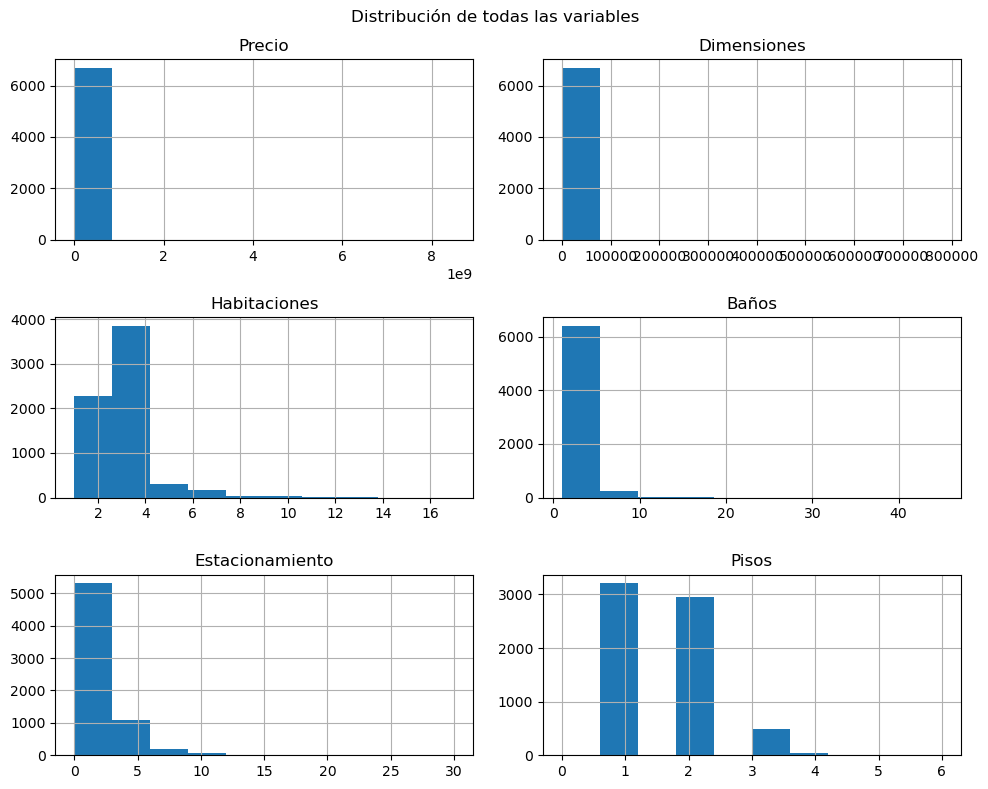

In [10]:
### ---- HISTOGRAMAS
df.hist(figsize=(10, 8))
plt.suptitle('Distribución de todas las variables')
plt.tight_layout()
plt.show()


In [11]:
### ---- DESCRIPCION DE ESTADISTICAS
df.describe().round(2)

,Precio,Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
count,6.688000e+03,6688.00,6688.00,6688.00,6688.00,6688.00
mean,1.033567e+07,575.90,3.02,2.69,2.07,1.61
std,1.068475e+08,11902.83,1.33,1.59,1.83,0.66
min,1.698270e+05,2.00,1.00,1.00,0.00,0.00
25%,2.613000e+06,98.00,2.00,2.00,1.00,1.00
50%,4.492700e+06,158.00,3.00,2.00,2.00,2.00
75%,8.750000e+06,300.00,4.00,3.00,2.00,2.00
max,8.495000e+09,780000.00,17.00,45.00,30.00,6.00


##### Correlación entre variables

Debido a la heterogeneidad y polarización del mercado inmobiliario nacional, no se espera correlación alta entre las variables numéricas. Esto se debe a que el valor de los inmuebles esta mayor condicionado por su ubicación y no tanto en sus características sísicas como tamaño o número de habitaciones.

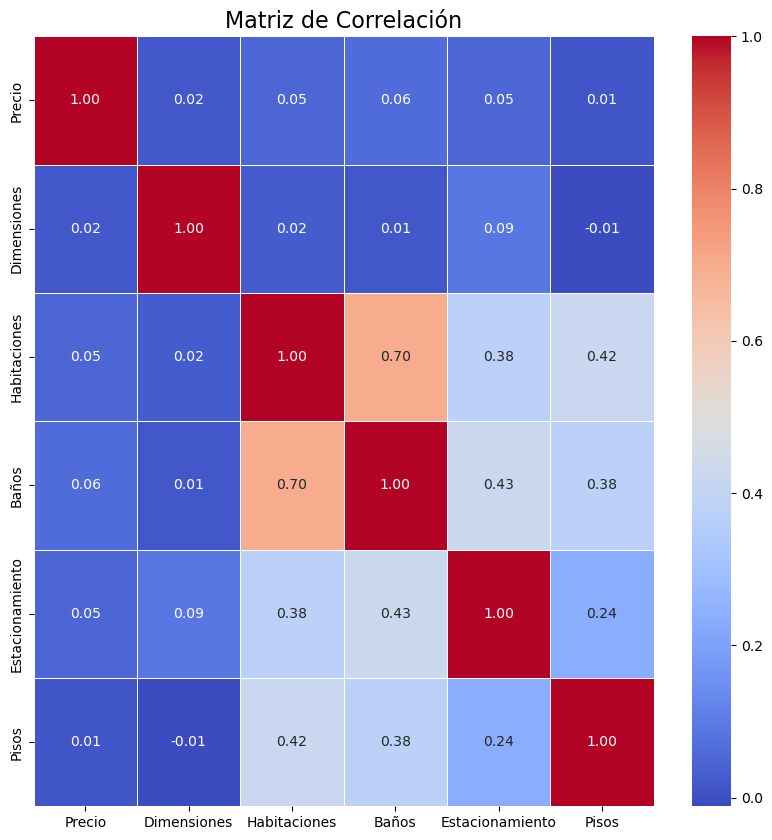

In [12]:
### ---- MATRIZ DE CORRELACIÓN
matriz_corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

Después de obtener estos resultados no se observa multicolinealidad severa por lo que no es estictamente necesario utilizar un PCA en este modelo, para preservar la interpretabilidad de sus variables.

## Inmuebles atípicos

Después de ver las distribuciones se esperan varios outliers, dada la heterogeneidad del mercado inmobiliario (clase social, zona, tipo de inmueble).

Los datos  atípicos se van a detectar con dos métodos complementarios: Modified Z-Score para outliers univariantes y Distancia de Mahalanobis para outliers multivariantes.

Con este último se hace una detección de inmuebles atípicos que son realmente “raros”. Por ejemplo, un departamento gigante y carísimo en una zona popular.

In [13]:
### ---- OUTLIERS
variables_num = [
    "Precio",
    "Dimensiones",
    "Habitaciones",
    "Baños",
    "Estacionamiento",
    "Pisos"]

# Modified Z-Score — detecta outliers por variable individual
def detect_outliers_modified_zscore(series, threshold=3.5):
    median = series.median()
    mad = np.median(np.abs(series - median))
    modified_z = 0.6745 * (series - median) / mad
    return np.abs(modified_z) > threshold

# Mahalanobis — detecta outliers considerando todas las variables juntas
def detect_outliers_mahalanobis(df, vars_list, threshold_percentile=99):
    X = df[vars_list].values
    mean = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.inv(cov)
    m_dist = np.array([mahalanobis(x, mean, inv_cov) for x in X])
    threshold = np.percentile(m_dist, threshold_percentile)
    outliers_mask = m_dist > threshold
    return outliers_mask, m_dist, threshold

# Outliers univariantes por variable
outliers_uni = {col: detect_outliers_modified_zscore(df[col]) for col in variables_num}
# Outliers multivariantes
outliers_multi, _, _ = detect_outliers_mahalanobis(df, variables_num)

print(f"Outliers Modified Z-Score: {np.any(np.column_stack(list(outliers_uni.values())), axis=1).sum()}")
print(f"Outliers Mahalanobis: {outliers_multi.sum()}")

Outliers Modified Z-Score: 1105
Outliers Mahalanobis: 67


Como se observa en los resultados de modified z-score, se identificaron 1105 observaciones atípicas en al menos una variable. Sin embargo,con la distancia de Mahalonobis, sólo 67 observaciones presentan patrones multivariantes atípicos considerando simultáneamente todas las características del inmueble.

Umbral Mahalanobis (percentil 99): 6.28
Outliers detectados: 67


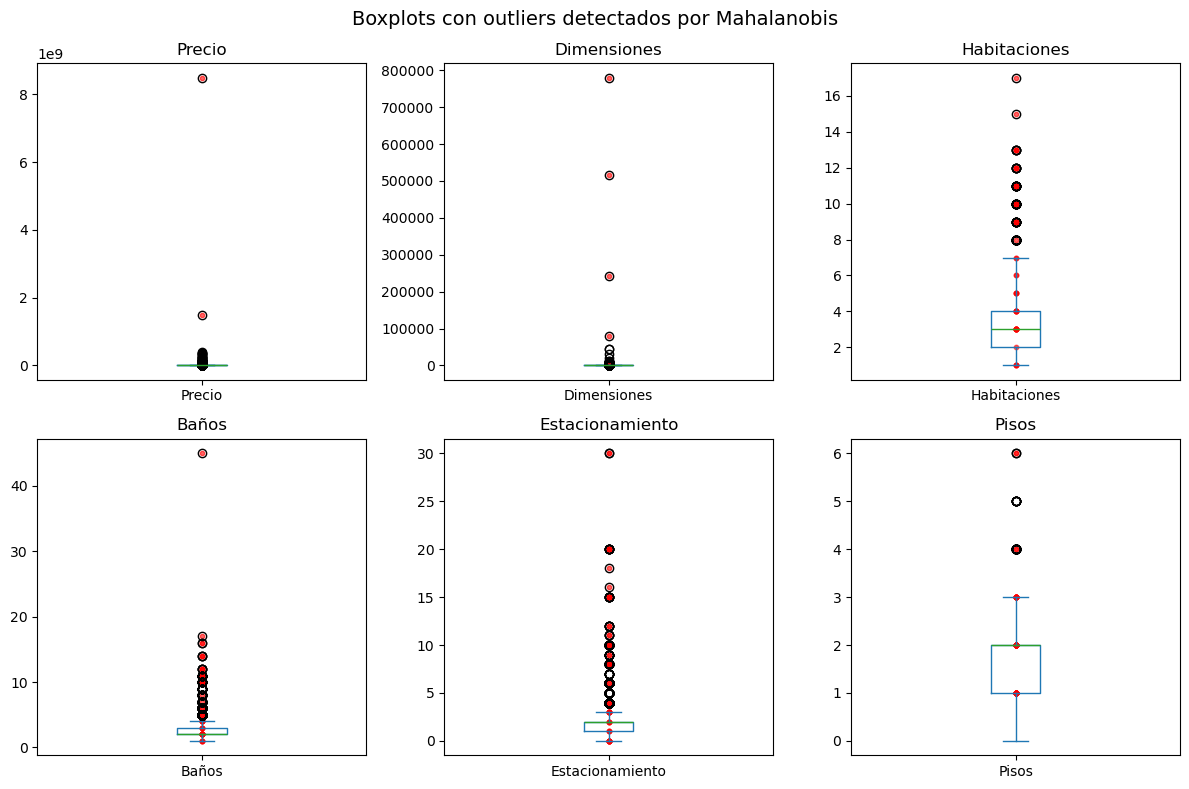

In [14]:
### ---- Boxplots con outliers Mahalanobis
outliers_mask, m_dist, threshold = detect_outliers_mahalanobis(df, variables_num)
print(f"Umbral Mahalanobis (percentil 99): {threshold:.2f}")
print(f"Outliers detectados: {outliers_mask.sum()}")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(variables_num):
    ax = axes[i]
    df[col].plot(kind='box', ax=ax)
    outliers_values = df[col][outliers_mask]
    ax.scatter(np.ones(outliers_values.shape[0]), outliers_values, color='red', alpha=0.6, s=10)
    ax.set_title(col)

plt.suptitle('Boxplots con outliers detectados por Mahalanobis', fontsize=14)
plt.tight_layout()
plt.show()

Aunque se identifican observaciones atípicas, debido a la naturaleza heterogénea del mercado inmobiliario, estos no se eliminan ya que representan segmentos reales del mercado.


## Variables de Mercado

Se incorporó una variable para representar los precios en relación a su ubicación, utilizando la mediana de la zona. Ya que al usar la mediana, los clusters se basan en el comportamiento central del mercado sin que los extremos distorsionen la comparación.

In [15]:
### ---- PRECIO MEDIANO POR NIVEL GEOGRÁFICO

mediana_estado_eda    = df.groupby('Estado')['Precio'].median()
mediana_municipio_eda = df.groupby('Municipio')['Precio'].median()
mediana_zona_eda      = df.groupby('Zona')['Precio'].median()
oferta_zona_eda       = df.groupby('Zona')['Precio'].count()

df['_Precio_mediana_zona_eda'] = df['Zona'].map(mediana_zona_eda)
df['_Oferta_zona_eda']         = df['Zona'].map(oferta_zona_eda)

La gráfica de la izquierda, analiza el precio mediano por estado con el objetivo de identificar diferencias regionales en el mercado inmobiliario. La de la derecha, analiza la distribución del número de inmuebles por zona con el fin de evaluar la representatividad de los datos a nivel geográfico.

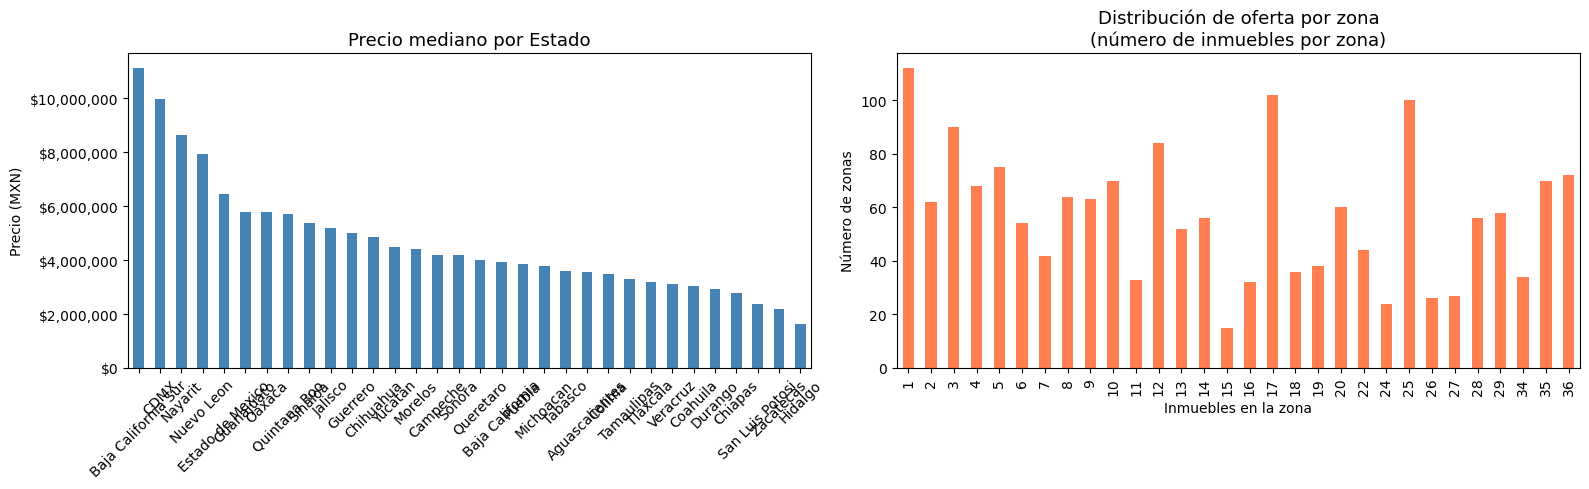


Registros en zonas con menos de 5 inmuebles: 332


In [16]:
### ---- GRAFICA DISTRIBUCION DE PRECIOS
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Precio mediano por estado
medianas_estado = df.groupby('Estado')['Precio'].median().sort_values(ascending=False)
medianas_estado.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Precio mediano por Estado', fontsize=13)
axes[0].set_ylabel('Precio (MXN)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Distribución de oferta por zona
df['_Oferta_zona_eda'].value_counts().sort_index().head(30).plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Distribución de oferta por zona\n(número de inmuebles por zona)', fontsize=13)
axes[1].set_xlabel('Inmuebles en la zona')
axes[1].set_ylabel('Número de zonas')

plt.tight_layout()
plt.show()

zonas_pocas = (df['_Oferta_zona_eda'] < 5).sum()
print(f"\nRegistros en zonas con menos de 5 inmuebles: {zonas_pocas:,}")

Se eliminan dichas columnas ya que fueron creadas únicamente para visualizar patrones iniciales.

In [17]:
# Limpiar columnas temporales del EDA — se recalcularán correctamente en preprocesamiento
df = df.drop(columns=['_Precio_mediana_zona_eda', '_Oferta_zona_eda'])
print("Columnas temporales eliminadas. Shape del df:", df.shape)

Columnas temporales eliminadas. Shape del df: (6688, 11)


## Transformaciones

Se probaron distintos métodos de transformación para saber cuál reduce más el sesgo dependiendo a la variable.

In [18]:
### ---- TRANSFORMACIONES
print(f"{'Variable':<15} {'Original':>10} {'Log':>10} {'Sqrt':>10} {'Box-Cox':>10} {'Yeo-J':>10}")
print("-" * 75)

for col in variables_num:
    data_col = df[col].dropna()
    original         = skew(data_col)
    log_skew         = skew(np.log1p(data_col))
    sqrt_skew        = skew(np.sqrt(data_col))
    try:
        bc, _ = boxcox(data_col + 1)
        bc_skew = skew(bc)
    except ValueError:
        bc_skew = np.nan
    yj, _ = yeojohnson(data_col)
    yj_skew = skew(yj)

    print(f"{col:<15} {original:>10.2f} {log_skew:>10.2f} {sqrt_skew:>10.2f} {bc_skew:>10.2f} {yj_skew:>10.2f}")

Variable          Original        Log       Sqrt    Box-Cox      Yeo-J
---------------------------------------------------------------------------
Precio               75.34       0.49      16.80      -0.02      -0.02
Dimensiones          55.53       1.23      28.79      -0.08      -0.08
Habitaciones          2.13       0.15       0.70      -0.01      -0.01
Baños                 4.54       0.43       1.03       0.01       0.01
Estacionamiento       4.06       0.18       0.27      -0.02      -0.02
Pisos                 0.91       0.39       0.48       0.11       0.11


Solamente se aplicó transformación logarítmica al precio y las dimensiones porque son las únicas con sesgo relevante. Las demás son discretas y tranformarlas dificultaria su interpretación.

In [19]:
# Aplicar transformación log
df["log_Precio"]= np.log(df["Precio"])
df["log_Dimensiones"] = np.log(df["Dimensiones"])

# Verificar que el sesgo bajó
print("Sesgo post-transformación:")
print(f"  Transformada Precio:      {skew(df['log_Precio']):.3f}")
print(f"  Transformadad Dimensiones: {skew(df['log_Dimensiones']):.3f}")

Sesgo post-transformación:
  Transformada Precio:      0.490
  Transformadad Dimensiones: 1.202


## Preprocesamiento

#### Split Train/Test

Se va a dividir el dataset para hacer una comparación del modelo. Train para aprender los centroides y las medianas de zona, y test para verificar que los clusters son estables

In [20]:
### ---- SPLIT-TEST
train, test = train_test_split(df,test_size=0.2,random_state=42,
    stratify=df['Tipo'] #para que tengan la misma proporción según el tipo
)

df_train = train.copy().reset_index(drop=True)
df_test  = test.copy().reset_index(drop=True)

#### Variables de Mercado

Para aproximar el valor del mercado, se calculo el precio mediano por zona para representar de nivel más robusto, el nivel de precios característico de cada ubicación, contemplando una oferta suficiente del 10 inmuebles por zona. 

In [21]:
### ---- VARIABLES DE MERCADO
umbral_zona = 10
umbral_municipio = 15

# ── Calcular medianas SOLO en train 
mediana_estado    = df_train.groupby('Estado')['log_Precio'].median()
mediana_municipio = df_train.groupby('Municipio')['log_Precio'].median()
mediana_zona      = df_train.groupby('Zona')['log_Precio'].median()       # ahora Zona = Estado+Municipio
oferta_zona_train = df_train.groupby('Zona')['log_Precio'].count()
oferta_municipio = (df_train.groupby('Municipio')['log_Precio'].count())

def asignar_precio_mercado(df_split, mediana_zona, mediana_municipio,
                            mediana_estado, oferta_zona_train,
                            oferta_municipio,
                            umbral_zona=umbral_zona, umbral_municipio=umbral_municipio):
    
    df_out = df_split.copy()
    df_out['Oferta_zona'] = (df_out['Zona'].map(oferta_zona_train).fillna(0))
    df_out['Oferta_municipio'] = (df_out['Municipio'].map(oferta_municipio).fillna(0))
    df_out['Precio_mediana_zona'] = df_out['Zona'].map(mediana_zona)
    df_out['Precio_mediana_municipio'] = (df_out['Municipio'].map(mediana_municipio))

    def fallback(row):
        # Nivel 1: Zona
        if (row['Oferta_zona'] >= umbral_zona and pd.notna(row['Precio_mediana_zona'])):
            return row['Precio_mediana_zona'], 'Zona'
        # Nivel 2: Municipio
        if (row['Oferta_municipio'] >= umbral_municipio and pd.notna(row['Precio_mediana_municipio'])):
            return row['Precio_mediana_municipio'], 'Municipio'
        # Nivel 3: Estado
        if row['Estado'] in mediana_estado.index:
            return mediana_estado[row['Estado']], 'Estado'
        
        return np.nan, 'Sin referencia'

    resultados = df_out.apply(fallback, axis=1)
    df_out['Precio_mercado_zona'] = [r[0] for r in resultados]
    df_out['Nivel_mediana'] = [r[1] for r in resultados]

    return df_out

# Aplicar a train y test por separado
df_train = asignar_precio_mercado(df_train, mediana_zona, mediana_municipio,
                                   mediana_estado, oferta_zona_train, oferta_municipio)
df_test  = asignar_precio_mercado(df_test,  mediana_zona, mediana_municipio,
                                   mediana_estado, oferta_zona_train, oferta_municipio)

print("--- DISTRIBUCIÓN DE NIVEL DE MEDIANA — TRAIN ---")
print(df_train['Nivel_mediana'].value_counts())
print("\n--- DISTRIBUCIÓN DE NIVEL DE MEDIANA — TEST ---")
print(df_test['Nivel_mediana'].value_counts())


print("--- PORCENTAJE DE USO ---")
print(round(df_train["Nivel_mediana"].value_counts(normalize=True)*100,2))

--- DISTRIBUCIÓN DE NIVEL DE MEDIANA — TRAIN ---
Nivel_mediana
Zona         4713
Estado        608
Municipio      29
Name: count, dtype: int64

--- DISTRIBUCIÓN DE NIVEL DE MEDIANA — TEST ---
Nivel_mediana
Zona         1161
Estado        169
Municipio       8
Name: count, dtype: int64
--- PORCENTAJE DE USO ---
Nivel_mediana
Zona         88.09
Estado       11.36
Municipio     0.54
Name: proportion, dtype: float64


#### Separación de por tipo

Debido a que casas y departamentos presentan distribuciones distintas, se construyeron modelos de clustering independientes para cada tipo de inmueble con el fin de obtener segmentos más homogéneos y comparables.

In [ ]:
# VARIABLES PARA CLUSTERING
features_clustering =  [
    'Precio_mercado_zona',#'Oferta_zona',
    'log_Dimensiones','Habitaciones','Baños','Estacionamiento','Pisos'
]

# -- Separar por tipo en TRAIN 
df_casas_train  = df_train[df_train['Tipo'] == 'Casa'].copy()
df_deptos_train = df_train[df_train['Tipo'] == 'Departamento'].copy()

# -- Separar por tipo en TEST 
df_casas_test   = df_test[df_test['Tipo'] == 'Casa'].copy()
df_deptos_test  = df_test[df_test['Tipo'] == 'Departamento'].copy()

print(f"Train — Casas: {len(df_casas_train):,}  |  Departamentos: {len(df_deptos_train):,}")
print(f"Test  — Casas: {len(df_casas_test):,}   |  Departamentos: {len(df_deptos_test):,}")

# ESCALAMIENTO
scaler_casas  = StandardScaler()
scaler_deptos = StandardScaler()

X_casas_train  = scaler_casas.fit_transform(df_casas_train[features_clustering])
X_casas_test   = scaler_casas.transform(df_casas_test[features_clustering])

X_deptos_train = scaler_deptos.fit_transform(df_deptos_train[features_clustering])
X_deptos_test  = scaler_deptos.transform(df_deptos_test[features_clustering])

print("Resumen escalamiento - Casas")
display(pd.DataFrame(X_casas_train,columns=features_clustering).describe().loc[['mean', 'std']])

print("Resumen escalamiento - Departamentos")
display(pd.DataFrame(X_deptos_train,columns=features_clustering).describe().loc[['mean', 'std']])

Train — Casas: 3,267  |  Departamentos: 2,083
Test  — Casas: 817   |  Departamentos: 521
Resumen escalamiento - Casas


,Precio_mercado_zona,Oferta_zona,log_Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
mean,-1.401729e-15,7.666554e-17,-5.198032e-16,-1.848673e-17,1.109204e-16,7.829672e-17,7.829672e-17
std,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00


Resumen escalamiento - Departamentos


,Precio_mercado_zona,Oferta_zona,log_Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
mean,3.481932e-15,-2.643642e-17,2.104680e-15,1.535018e-16,1.210959e-16,-3.411151e-17,-3.325872e-16
std,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00


## Clustering

Para los modelos de clustering se utilizaron variables que describen tanto las características físicas del inmueble como el contexto económico del mercado local. Dado que casas y departamentos presentan patrones estructurales distintos, se desarrollaron procesos de segmentación independientes para cada tipo de inmueble.

- **KMeans++**: basado en centroides
- **Agglomerative Clustering**: clustering jerárquico


Para evaluar los clusters se utilizan las métricas:
- Elbow: Mide la reducción de la variabilidad interna. 
- Silhouette: Mide separación entre clusters. (Valor alto)
- Calinski-Harabasz: Premia clusters compactos y separados. (Valor alto)
- Davies-Boouldin: Mide similitud entre clusters. (Valor bajo)

#### Clusters

Se evaluaron distintas configuraciones de k entre 2 y 10 clusters con el fin de identificar estructuras potenciales en los datos. Posteriormente se seleccionó el número de clusters considerando simultáneamente métricas de calidad, interpretabilidad y tamaño de los segmentos obtenidos.

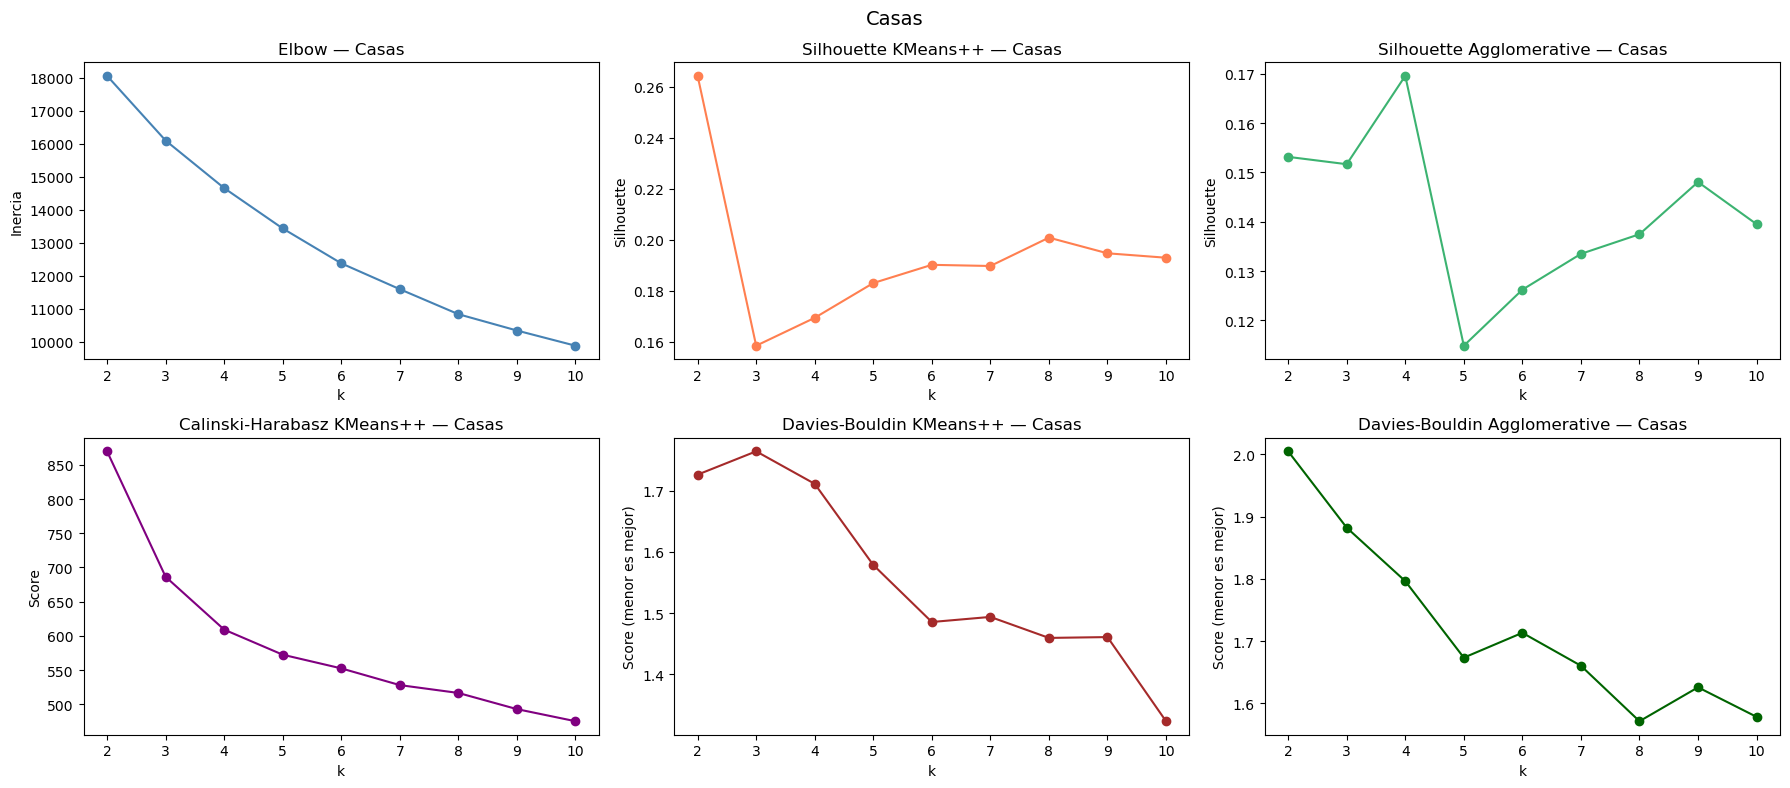

,k,silhouette_km,calinski_km,davies_km,silhouette_agg,calinski_agg,davies_agg
0,2,0.2644,869.7004,1.7262,0.1532,617.3475,2.0051
1,3,0.1584,686.3416,1.7644,0.1517,519.1903,1.8823
2,4,0.1693,609.1726,1.7112,0.1696,482.4606,1.7964
3,5,0.1830,572.5172,1.5786,0.1149,466.5004,1.6733
4,6,0.1901,552.5335,1.4854,0.1262,448.4584,1.7133
5,7,0.1897,528.0970,1.4937,0.1335,426.6101,1.6603
6,8,0.2008,516.6216,1.4594,0.1375,415.0571,1.5711
7,9,0.1947,492.9985,1.4607,0.1481,407.1578,1.6256
8,10,0.1929,475.3217,1.3232,0.1395,394.8825,1.5782


Mejor Silhouette Casas: k=2
Mejor Calinski Casas: k=2
Mejor Davies Casas: k=10


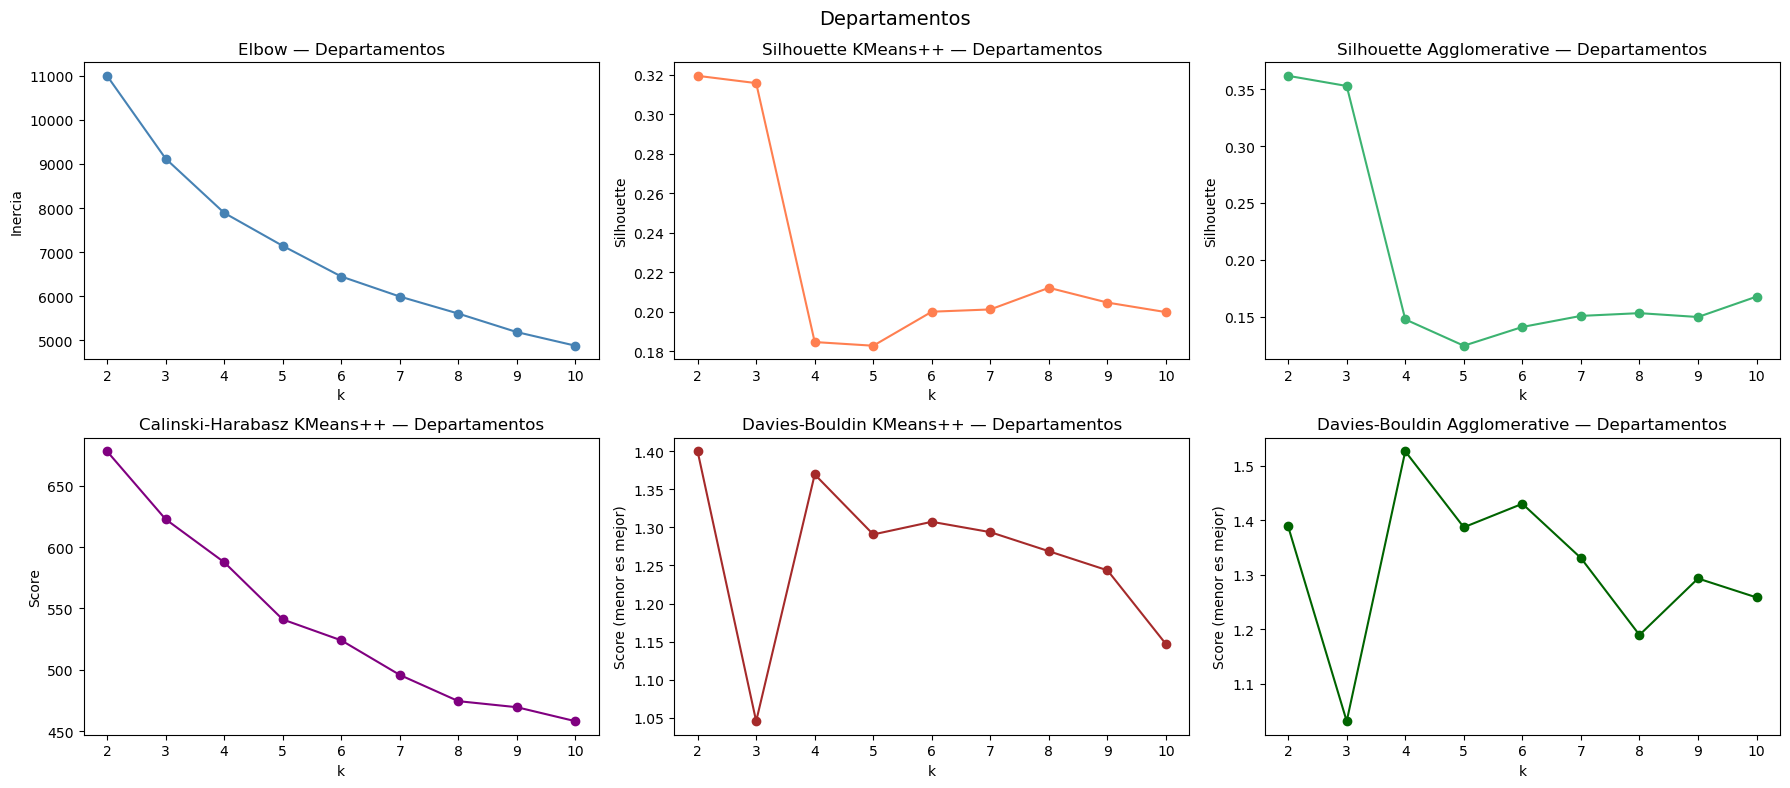

,k,silhouette_km,calinski_km,davies_km,silhouette_agg,calinski_agg,davies_agg
0,2,0.3194,677.9097,1.4001,0.3617,597.4113,1.3884
1,3,0.3157,622.6126,1.0452,0.3527,564.5130,1.0310
2,4,0.1846,587.6162,1.3697,0.1477,513.3688,1.5263
3,5,0.1828,541.0536,1.2908,0.1246,462.9658,1.3869
4,6,0.2000,524.0255,1.3074,0.1411,444.0429,1.4301
5,7,0.2011,495.8564,1.2938,0.1508,421.1698,1.3305
6,8,0.2121,474.5240,1.2687,0.1532,407.4409,1.1893
7,9,0.2046,469.5954,1.2436,0.1498,401.1737,1.2930
8,10,0.1998,458.1909,1.1465,0.1677,395.3504,1.2582


Mejor Silhouette Departamentos: k=2
Mejor Calinski Departamentos: k=2
Mejor Davies Departamentos: k=3


In [23]:
### ---- MÉTRICAS DE VALIDACIÓN DE CLUSTERING 
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

def evaluar_k(X_train, nombre, k_min=2, k_max=10):
    inercias        = []
    silhouettes_km  = []
    silhouettes_agg = []
    calinski_km     = []
    davies_km       = []
    calinski_agg    = []
    davies_agg      = []
    k_range = range(k_min, k_max + 1)

    for k in k_range:
        # KMeans++
        km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels_km = km.fit_predict(X_train)
        inercias.append(km.inertia_)
        silhouettes_km.append(silhouette_score(X_train, labels_km))
        calinski_km.append(calinski_harabasz_score(X_train, labels_km))
        davies_km.append(davies_bouldin_score(X_train, labels_km))

        # Agglomerative
        agg = AgglomerativeClustering(n_clusters=k)
        labels_agg = agg.fit_predict(X_train)
        silhouettes_agg.append(silhouette_score(X_train, labels_agg))
        calinski_agg.append(calinski_harabasz_score(X_train, labels_agg))
        davies_agg.append(davies_bouldin_score(X_train, labels_agg))

    # Visualización
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))

    axes[0,0].plot(k_range, inercias, 'o-', color='steelblue')
    axes[0,0].set_title(f'Elbow — {nombre}')
    axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inercia')

    axes[0,1].plot(k_range, silhouettes_km, 'o-', color='coral')
    axes[0,1].set_title(f'Silhouette KMeans++ — {nombre}')
    axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette')

    axes[0,2].plot(k_range, silhouettes_agg, 'o-', color='mediumseagreen')
    axes[0,2].set_title(f'Silhouette Agglomerative — {nombre}')
    axes[0,2].set_xlabel('k'); axes[0,2].set_ylabel('Silhouette')

    axes[1,0].plot(k_range, calinski_km, 'o-', color='purple')
    axes[1,0].set_title(f'Calinski-Harabasz KMeans++ — {nombre}')
    axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('Score')

    axes[1,1].plot(k_range, davies_km, 'o-', color='brown')
    axes[1,1].set_title(f'Davies-Bouldin KMeans++ — {nombre}')
    axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('Score (menor es mejor)')

    axes[1,2].plot(k_range, davies_agg, 'o-', color='darkgreen')
    axes[1,2].set_title(f'Davies-Bouldin Agglomerative — {nombre}')
    axes[1,2].set_xlabel('k'); axes[1,2].set_ylabel('Score (menor es mejor)')

    plt.suptitle(nombre, fontsize=14)
    plt.tight_layout()
    plt.show()

    resultados = pd.DataFrame({
    "k": list(k_range),
    "silhouette_km": silhouettes_km,
    "calinski_km": calinski_km,
    "davies_km": davies_km,
    "silhouette_agg": silhouettes_agg,
    "calinski_agg": calinski_agg,
    "davies_agg": davies_agg
    })
    display(resultados.round(4))

    return  resultados

resultados_casas = evaluar_k(X_casas_train,"Casas")

best_silhouette_C = resultados_casas.loc[resultados_casas["silhouette_km"].idxmax(),"k"]
best_calinski_C = resultados_casas.loc[resultados_casas["calinski_km"].idxmax(),"k"]
best_davies_C = resultados_casas.loc[resultados_casas["davies_km"].idxmin(),"k"]
print(f"Mejor Silhouette Casas: k={best_silhouette_C}")
print(f"Mejor Calinski Casas: k={best_calinski_C}")
print(f"Mejor Davies Casas: k={best_davies_C}")

resultados_deptos = evaluar_k(X_deptos_train,"Departamentos")

best_silhouette_D = resultados_deptos.loc[resultados_deptos["silhouette_km"].idxmax(),"k"]
best_calinski_D = resultados_deptos.loc[resultados_deptos["calinski_km"].idxmax(),"k"]
best_davies_D = resultados_deptos.loc[resultados_deptos["davies_km"].idxmin(),"k"]
print(f"Mejor Silhouette Departamentos: k={best_silhouette_D}")
print(f"Mejor Calinski Departamentos: k={best_calinski_D}")
print(f"Mejor Davies Departamentos: k={best_davies_D}")

Aunque algunas métricas alcanzan sus valores óptimos con k=2, esta solución genera segmentos demasiado amplios y poco útiles para representar la diversidad del mercado inmobiliario. Por ello se analizaron configuraciones adicionales con mayor granularidad.

**Casas**

Considerando tanto las métricas como las caracteristicas y la interpretabilidad, se van a probar valores mas altos de k para observar los tamaños de los grupos y lo que representarían.

In [24]:
# Distribución K clusters
for k in [5,6,8]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20)

    labels = km.fit_predict(X_casas_train)

    print(f"\n=== k={k} ===")
    print(pd.Series(labels).value_counts().sort_index())



=== k=5 ===
0    1177
1     286
2     963
3     731
4     110
Name: count, dtype: int64

=== k=6 ===
0     238
1     877
2    1045
3     657
4     114
5     336
Name: count, dtype: int64

=== k=8 ===
0    423
1    453
2    103
3    752
4     75
5    318
6    853
7    290
Name: count, dtype: int64


Con estos resultados se determino que el k=6 es la la alternativa más adecuada, ya que mantiene tamaños de clusters razonables en cuanto a la interpretabilidad del mercado. Entonces ahora se va a analizar el perfil de cada clusters para analizar significado de cada cluster.

In [25]:
kmeans_casas = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20)

df_casas_train["Cluster"] = kmeans_casas.fit_predict(X_casas_train)

perfil_casas = (df_casas_train.groupby("Cluster")[features_clustering].median())

perfil_casas

,Precio_mercado_zona,Oferta_zona,log_Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
Cluster,,,,,,,
0,15.252023,50.0,7.111500,4.0,4.0,6.0,2.0
1,15.394489,123.0,5.278115,3.0,3.0,2.0,2.0
2,14.946913,32.0,4.964033,3.0,2.0,2.0,2.0
3,15.811666,49.0,5.963579,4.0,3.0,2.0,2.0
4,15.456671,79.0,6.612009,7.0,7.0,3.0,2.0
5,15.537679,57.0,5.491000,4.0,4.0,2.0,3.0


**Departamentos**

En el caso de los departamentos se observó que los valores de k medios son los que mostraron un mejor comportamiento en la evaluación de las métricas. Por lo que ahora se va a evaluar la distribución de los inmuebles en los clustes.

In [26]:
for k in [3,4,5]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20)

    labels = km.fit_predict(X_deptos_train)

    print(f"\n=== k={k} ===")
    print(pd.Series(labels).value_counts().sort_index())


=== k=3 ===
0     576
1    1505
2       2
Name: count, dtype: int64

=== k=4 ===
0    804
1    899
2    378
3      2
Name: count, dtype: int64

=== k=5 ===
0    550
1    363
2      2
3    519
4    649
Name: count, dtype: int64


En este caso se eligió un k=4 por presentar una distribución más balanceada de observaciones entre clusters y una representación más interpretable del mercado.

In [27]:
kmeans_dpto = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20)

df_deptos_train["Cluster"] = kmeans_dpto.fit_predict(X_deptos_train)

perfil_dpto = (df_deptos_train.groupby("Cluster")[features_clustering].median())

perfil_dpto

,Precio_mercado_zona,Oferta_zona,log_Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
Cluster,,,,,,,
0,15.066843,55.0,4.189655,2.0,1.0,1.0,1.0
1,15.412876,100.0,4.718499,2.0,2.0,2.0,1.0
2,15.424948,79.5,5.480639,3.0,3.0,2.0,1.0
3,15.293578,135.5,4.776965,2.0,2.5,2.0,2.5


#### Ajuste del clustering

In [28]:

mejor_k_km_casas = 6
mejor_k_agg_casas =6
mejor_k_km_deptos = 4
mejor_k_agg_deptos = 4

### ---- CLUSTERING CASAS
km_casas = KMeans(n_clusters=mejor_k_km_casas, init='k-means++', random_state=42, n_init=10)
df_casas_train['Cluster_KMeans'] = km_casas.fit_predict(X_casas_train)
df_casas_test['Cluster_KMeans']  = km_casas.predict(X_casas_test)   # predict, no fit

agg_casas = AgglomerativeClustering(n_clusters=mejor_k_agg_casas)
df_casas_train['Cluster_Agg'] = agg_casas.fit_predict(X_casas_train)
# Agglomerative no tiene predict — asignamos el cluster del vecino más cercano en train
from sklearn.neighbors import KNeighborsClassifier
knn_agg_casas = KNeighborsClassifier(n_neighbors=1)
knn_agg_casas.fit(X_casas_train, df_casas_train['Cluster_Agg'])
df_casas_test['Cluster_Agg'] = knn_agg_casas.predict(X_casas_test)

### ---- CLUSTERING DEPARTAMENTOS
km_deptos = KMeans(n_clusters=mejor_k_km_deptos, init='k-means++', random_state=42, n_init=10)
df_deptos_train['Cluster_KMeans'] = km_deptos.fit_predict(X_deptos_train)
df_deptos_test['Cluster_KMeans']  = km_deptos.predict(X_deptos_test)

agg_deptos = AgglomerativeClustering(n_clusters=mejor_k_agg_deptos)
df_deptos_train['Cluster_Agg'] = agg_deptos.fit_predict(X_deptos_train)
knn_agg_deptos = KNeighborsClassifier(n_neighbors=1)
knn_agg_deptos.fit(X_deptos_train, df_deptos_train['Cluster_Agg'])
df_deptos_test['Cluster_Agg'] = knn_agg_deptos.predict(X_deptos_test)

print("=== DISTRIBUCIÓN DE CLUSTERS — TRAIN ===")
print(f"Casas   KMeans++: {df_casas_train['Cluster_KMeans'].value_counts().sort_index().to_dict()}")
print(f"Casas   Agg:      {df_casas_train['Cluster_Agg'].value_counts().sort_index().to_dict()}")
print(f"Deptos  KMeans++: {df_deptos_train['Cluster_KMeans'].value_counts().sort_index().to_dict()}")
print(f"Deptos  Agg:      {df_deptos_train['Cluster_Agg'].value_counts().sort_index().to_dict()}")

print("\n=== DISTRIBUCIÓN DE CLUSTERS — TEST ===")
print(f"Casas   KMeans++: {df_casas_test['Cluster_KMeans'].value_counts().sort_index().to_dict()}")
print(f"Deptos  KMeans++: {df_deptos_test['Cluster_KMeans'].value_counts().sort_index().to_dict()}")

=== DISTRIBUCIÓN DE CLUSTERS — TRAIN ===
Casas   KMeans++: {0: 1037, 1: 885, 2: 654, 3: 121, 4: 331, 5: 239}
Casas   Agg:      {0: 991, 1: 751, 2: 117, 3: 371, 4: 593, 5: 444}
Deptos  KMeans++: {0: 804, 1: 899, 2: 378, 3: 2}
Deptos  Agg:      {0: 772, 1: 399, 2: 2, 3: 910}

=== DISTRIBUCIÓN DE CLUSTERS — TEST ===
Casas   KMeans++: {0: 263, 1: 226, 2: 154, 3: 34, 4: 90, 5: 50}
Deptos  KMeans++: {0: 208, 1: 222, 2: 90, 3: 1}


In [29]:
# ============================================================
# CLUSTER DEFINITIVO KMEANS
# ============================================================
df_casas_train["Cluster"] = ("C" +(df_casas_train["Cluster_KMeans"] + 1).astype(str))
df_casas_test["Cluster"] = ("C" +(df_casas_test["Cluster_KMeans"] + 1).astype(str))

df_deptos_train['Cluster'] = ("D" +(df_deptos_train["Cluster_KMeans"] + 1).astype(str))
df_deptos_test['Cluster']  = ("D" +(df_deptos_test["Cluster_KMeans"] + 1).astype(str))

# Reconstruir train y test completos (casas + departamentos)
df_train_final = pd.concat([df_casas_train, df_deptos_train], axis=0).reset_index(drop=True)
df_test_final  = pd.concat([df_casas_test,  df_deptos_test],  axis=0).reset_index(drop=True)

# Verificación: ningún cluster debe mezclar tipos
print(f"Clusters de casas:         {sorted(df_casas_train['Cluster'].unique())}")
print(f"Clusters de departamentos: {sorted(df_deptos_train['Cluster'].unique())}")
print(f"\nDistribución de clusters en train:")
print(df_train_final.groupby(['Cluster', 'Tipo']).size())

Clusters de casas:         ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
Clusters de departamentos: ['D1', 'D2', 'D3', 'D4']

Distribución de clusters en train:
Cluster  Tipo        
C1       Casa            1037
C2       Casa             885
C3       Casa             654
C4       Casa             121
C5       Casa             331
C6       Casa             239
D1       Departamento     804
D2       Departamento     899
D3       Departamento     378
D4       Departamento       2
dtype: int64


In [30]:
df_deptos_train[
    df_deptos_train["Cluster"] == "D3"
]

,Estado,Municipio,Colonia,Precio,Dimensiones,Habitaciones,Baños,Tipo,Estacionamiento,Pisos,...,log_Dimensiones,Oferta_zona,Oferta_municipio,Precio_mediana_zona,Precio_mediana_municipio,Precio_mercado_zona,Nivel_mediana,Cluster,Cluster_KMeans,Cluster_Agg
26,CDMX,Cuajimalpa de Morelos,El Yaqui,17000000.0,340.0,3,3,Departamento,3,1,...,5.828946,49,49,16.380460,16.380460,16.380460,Zona,D3,2,1
36,Nuevo Leon,San Pedro Garza Garcia,Valle del Campestre,42000000.0,300.0,3,2,Departamento,3,1,...,5.703782,44,44,17.369939,17.369939,17.369939,Zona,D3,2,1
45,Sinaloa,Mazatlan,Telleria,22281000.0,428.0,4,4,Departamento,2,1,...,6.059123,137,137,15.500056,15.500056,15.500056,Zona,D3,2,1
53,Morelos,Cuernavaca,Lomas de Cortes,4500000.0,158.0,3,3,Departamento,2,1,...,5.062595,100,100,15.336102,15.336102,15.336102,Zona,D3,2,3
78,Queretaro,Queretaro,Juriquilla,7737345.0,177.0,3,3,Departamento,2,1,...,5.176150,123,124,15.412876,15.413887,15.412876,Zona,D3,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5289,Guanajuato,San Miguel de Allende,Arcos de San Miguel,5000000.0,167.0,3,3,Departamento,2,1,...,5.117994,88,88,15.665371,15.665371,15.665371,Zona,D3,2,1
5295,Guerrero,Acapulco,Brisas del Marques,10000000.0,400.0,4,4,Departamento,2,1,...,5.991465,213,213,15.424948,15.424948,15.424948,Zona,D3,2,1
5312,CDMX,Cuajimalpa de Morelos,Contadero,12700000.0,160.0,3,3,Departamento,2,1,...,5.075174,49,49,16.380460,16.380460,16.380460,Zona,D3,2,1
5320,CDMX,Coyoacan,Talpan,10500000.0,240.0,3,3,Departamento,3,1,...,5.480639,18,18,16.406683,16.406683,16.406683,Zona,D3,2,1


#### Visualización PCA - TSNE

PCA se utiliza únicamente como herramienta visual exploratoria y no como criterio de validación de los clusters.

Calculando PCA para Casas...


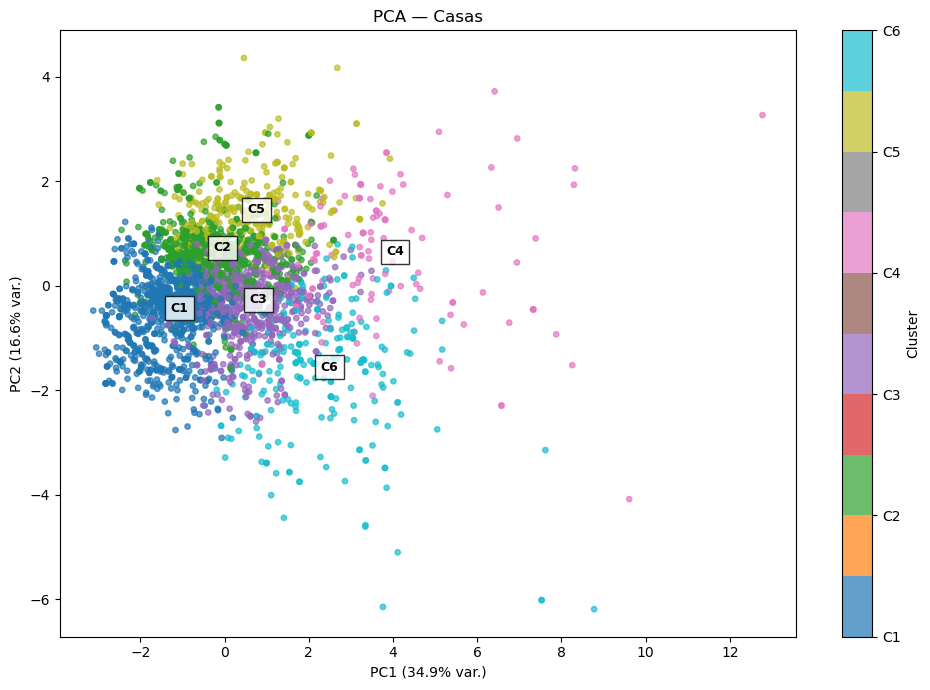

Varianza explicada total: 51.46%
Calculando PCA para Departamentos...


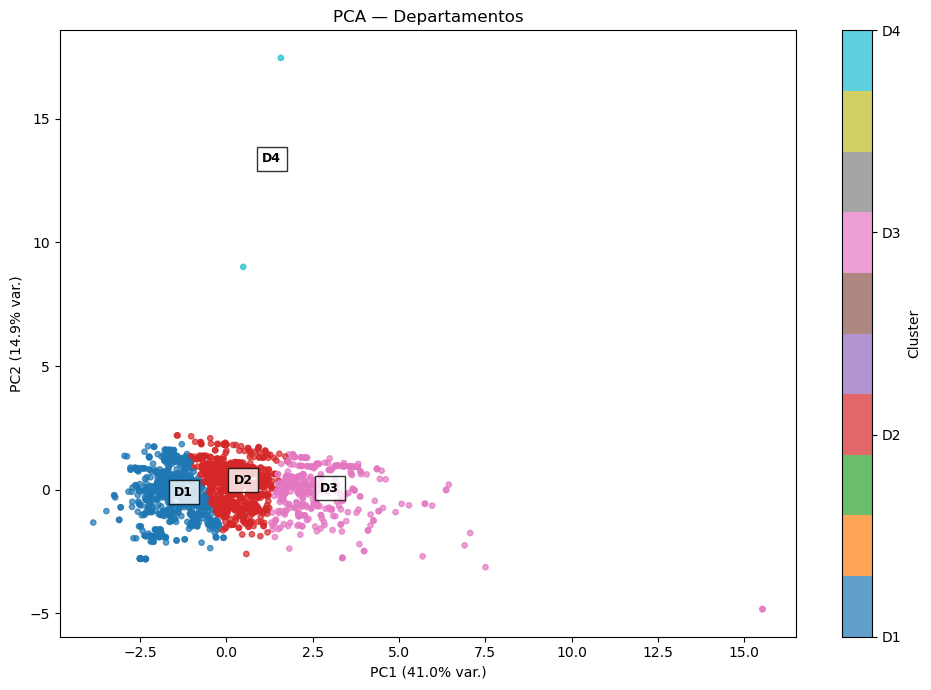

Varianza explicada total: 55.81%


In [33]:
from sklearn.decomposition import PCA

def visualizar_pca(X_train, df_sub, nombre):

    print(f"Calculando PCA para {nombre}...")

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_train)

    # --- Extraer número del cluster para colorear (funciona con "C1","C2"... y "D1","D2"...)
    cluster_labels = df_sub["Cluster"].unique()
    cluster_sorted = sorted(cluster_labels)
    cluster_to_num = {label: i for i, label in enumerate(cluster_sorted)}
    cluster_num    = df_sub["Cluster"].map(cluster_to_num)

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_num,          # ahora sí son números
        cmap="tab10",
        alpha=0.7,
        s=15)

    for cluster in cluster_sorted:

        idx = df_sub["Cluster"] == cluster

        plt.text(
            X_pca[idx, 0].mean(),
            X_pca[idx, 1].mean(),
            cluster,             # "C1", "C2"... o "D1", "D2"... directamente
            fontsize=9,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.8))

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
    plt.title(f"PCA — {nombre}")

    # Colorbar con etiquetas legibles
    cbar = plt.colorbar(scatter)
    cbar.set_ticks(range(len(cluster_sorted)))
    cbar.set_ticklabels(cluster_sorted)
    cbar.set_label("Cluster")

    plt.tight_layout()
    plt.show()

    print(f"Varianza explicada total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

visualizar_pca(X_casas_train,  df_casas_train,  "Casas")
visualizar_pca(X_deptos_train, df_deptos_train, "Departamentos")

t-SNE está diseñado para proyectar datos de alta dimensión a 2D intentando preservar vecindades locales y de esta manera ver como se distriuyen los clusters

Calculando t-SNE para Casas...


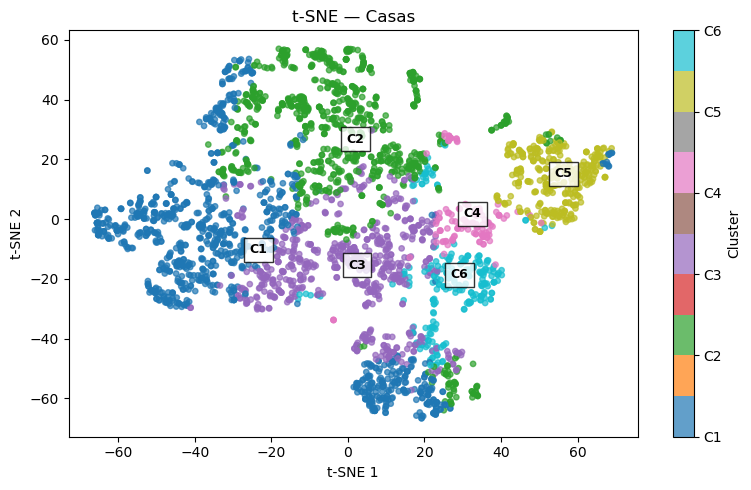

Calculando t-SNE para Departamentos...


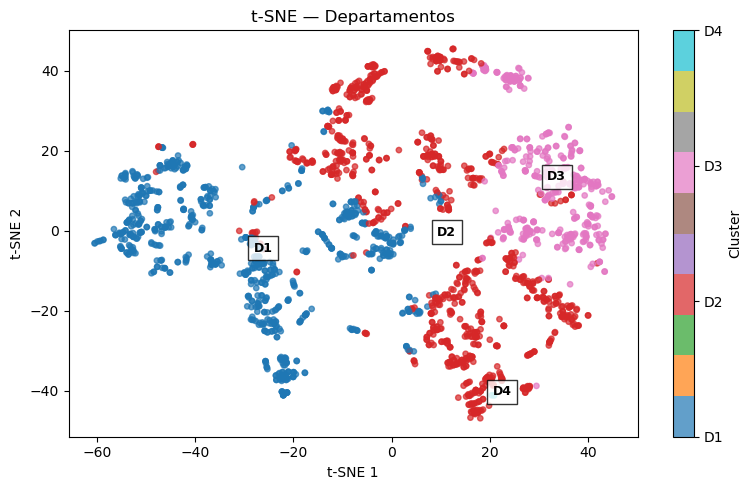

In [35]:
from sklearn.manifold import TSNE

def visualizar_tsne(X_train, df_sub, nombre):

    print(f"Calculando t-SNE para {nombre}...")

    tsne = TSNE(n_components=2, perplexity=40, random_state=42)
    X_tsne = tsne.fit_transform(X_train)

    # Mismo patrón que PCA
    cluster_sorted = sorted(df_sub["Cluster"].unique())
    cluster_to_num = {label: i for i, label in enumerate(cluster_sorted)}
    cluster_num    = df_sub["Cluster"].map(cluster_to_num)

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=cluster_num,
        cmap="tab10",
        alpha=0.7,
        s=15)

    for cluster in cluster_sorted:

        idx = df_sub["Cluster"] == cluster

        plt.text(
            X_tsne[idx, 0].mean(),
            X_tsne[idx, 1].mean(),
            cluster,             # "C1"/"D1" directo, sin f"C{cluster}"
            fontsize=9,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.8))

    plt.title(f"t-SNE — {nombre}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

    cbar = plt.colorbar(scatter)
    cbar.set_ticks(range(len(cluster_sorted)))
    cbar.set_ticklabels(cluster_sorted)
    cbar.set_label("Cluster")

    plt.tight_layout()
    plt.show()

visualizar_tsne(X_casas_train,  df_casas_train,  "Casas")
visualizar_tsne(X_deptos_train, df_deptos_train, "Departamentos")

Ahora se va a evaluar la estabilidad de los clusters

In [36]:
from sklearn.metrics import silhouette_score

sil_train = silhouette_score(X_casas_train, df_casas_train['Cluster_KMeans'])
sil_test  = silhouette_score(X_casas_test,  df_casas_test['Cluster_KMeans'])
print(f"Silhouette Casas — Train: {sil_train:.4f} | Test: {sil_test:.4f}")

Silhouette Casas — Train: 0.1901 | Test: 0.1891


# Conclusión

La segmentación no se realizó exclusivamente a partir de variables de mercado ni únicamente mediante atributos físicos de las propiedades. Se utilizaron ambos tipos de variables con el propósito de identificar segmentos que reflejaran simultáneamente las condiciones comerciales y las características de los inmuebles, permitiendo obtener grupos más representativos y útiles para la toma de decisiones inmobiliarias.

In [37]:
### ---- INTERPRETABILIDAD DE CLUSTERS
# Resumen por cluster usando valores originales
cluster_summary = (
    df_train_final
    .groupby('Cluster')[[
        'Precio', 'Dimensiones','Habitaciones',
        'Baños','Estacionamiento','Pisos','Oferta_zona'
    ]]
    .median().round(2))

cluster_summary['N_registros'] = df_train_final['Cluster'].value_counts().sort_index()

print("=== RESUMEN DE CLUSTERS ===")

for cluster_id, row in cluster_summary.iterrows():
    print(f"\nCluster {cluster_id}:")
    print(f"  - Precio mediano: {row['Precio']:,.2f}")
    print(f"  - Dimensiones medianas: {row['Dimensiones']:,.2f} m2")
    print(f"  - Habitaciones: {row['Habitaciones']}, Baños: {row['Baños']}")
    print(f"  - Estacionamientos: {row['Estacionamiento']}, Pisos: {row['Pisos']}")
    print(f"  - Oferta en zona: {row['Oferta_zona']} inmuebles")
    print(f"  - Registros en cluster: {row['N_registros']}")

=== RESUMEN DE CLUSTERS ===

Cluster C1:
  - Precio mediano: 2,500,000.00
  - Dimensiones medianas: 143.17 m2
  - Habitaciones: 3.0, Baños: 2.0
  - Estacionamientos: 2.0, Pisos: 2.0
  - Oferta en zona: 32.0 inmuebles
  - Registros en cluster: 1037.0

Cluster C2:
  - Precio mediano: 4,600,000.00
  - Dimensiones medianas: 193.00 m2
  - Habitaciones: 3.0, Baños: 3.0
  - Estacionamientos: 2.0, Pisos: 2.0
  - Oferta en zona: 123.0 inmuebles
  - Registros en cluster: 885.0

Cluster C3:
  - Precio mediano: 10,500,000.00
  - Dimensiones medianas: 389.50 m2
  - Habitaciones: 4.0, Baños: 3.0
  - Estacionamientos: 2.0, Pisos: 2.0
  - Oferta en zona: 49.0 inmuebles
  - Registros en cluster: 654.0

Cluster C4:
  - Precio mediano: 23,500,000.00
  - Dimensiones medianas: 700.00 m2
  - Habitaciones: 7.0, Baños: 7.0
  - Estacionamientos: 3.0, Pisos: 2.0
  - Oferta en zona: 79.0 inmuebles
  - Registros en cluster: 121.0

Cluster C5:
  - Precio mediano: 7,700,000.00
  - Dimensiones medianas: 247.00 m2
  

La segmentación permitió identificar distintos niveles de mercado inmobiliario. Estos clusters servirán como variable explicativa en la etapa de predicción, permitiendo capturar diferencias estructurales en el comportamiento de los precios.

In [38]:
# Exportar data definitivo para utilizarlo en el documento de predicción
df_train_final.to_excel("clusters_inmuebles.xlsx", index=False)

In [41]:
import pandas as pd
import folium

# ==================================================
# Coordenadas por estado
# ==================================================

coords_estados = {
    "Aguascalientes": [21.8823, -102.2826],
    "Baja California": [32.6519, -115.4689],
    "Baja California Sur": [24.1426, -110.3128],
    "Campeche": [19.8301, -90.5349],
    "Coahuila": [25.4380, -100.9730],
    "Colima": [19.2433, -103.7250],
    "Chiapas": [16.7569, -93.1292],
    "Chihuahua": [28.6320, -106.0691],
    "Ciudad de México": [19.4326, -99.1332],
    "Durango": [24.0277, -104.6532],
    "Guanajuato": [21.0190, -101.2574],
    "Guerrero": [17.5506, -99.5058],
    "Hidalgo": [20.0911, -98.7624],
    "Jalisco": [20.6597, -103.3496],
    "México": [19.3574, -99.0682],
    "Michoacán": [19.5665, -101.7068],
    "Morelos": [18.6813, -99.1013],
    "Nayarit": [21.7514, -104.8455],
    "Nuevo León": [25.6866, -100.3161],
    "Oaxaca": [17.0594, -96.7216],
    "Puebla": [19.0414, -98.2063],
    "Querétaro": [20.5888, -100.3899],
    "Quintana Roo": [21.1619, -86.8515],
    "San Luis Potosí": [22.1565, -100.9855],
    "Sinaloa": [24.8091, -107.3940],
    "Sonora": [29.0729, -110.9559],
    "Tabasco": [17.9869, -92.9303],
    "Tamaulipas": [25.4380, -99.9440],
    "Tlaxcala": [19.3182, -98.1996],
    "Veracruz": [19.1738, -96.1342],
    "Yucatán": [20.9674, -89.5926],
    "Zacatecas": [22.7709, -102.5833]
}

# ==================================================
# Limpieza
# ==================================================

df = df_train_final.copy()

df["Estado"] = (
    df["Estado"]
    .astype(str)
    .str.strip()
)

# ==================================================
# Conteo total por estado
# ==================================================

conteo_estado = df["Estado"].value_counts()

# ==================================================
# Distribución porcentual
# ==================================================

dist = (
    df.groupby(["Estado", "Cluster"])
      .size()
      .unstack(fill_value=0)
)

dist_pct = (
    dist.div(dist.sum(axis=1), axis=0)
        .round(3) * 100
)

# ==================================================
# Cluster dominante (solo para color)
# ==================================================

cluster_dominante = dist.idxmax(axis=1)

# ==================================================
# Colores
# ==================================================

colores = {
    "C1":"red",
    "C2":"blue",
    "C3":"green",
    "C4":"purple",
    "C5":"orange",
    "C6":"brown",
    "D1":"pink",
    "D2":"black",
    "D3":"gray",
    "D4":"gold"
}

# ==================================================
# Crear mapa
# ==================================================

m = folium.Map(
    location=[23.6345, -102.5528],
    zoom_start=5,
    tiles="CartoDB positron"
)

# ==================================================
# Dibujar estados
# ==================================================

for estado in dist_pct.index:

    if estado not in coords_estados:
        continue

    lat, lon = coords_estados[estado]

    dominante = cluster_dominante[estado]

    color = colores.get(dominante, "gray")

    total = conteo_estado[estado]

    size = max(8, total / 20)

    # --------------------------------------
    # Construir popup
    # --------------------------------------

    popup = f"""
    <h4>{estado}</h4>

    <b>Total propiedades:</b> {total}<br><br>

    <b>Distribución de clusters:</b><br>
    """

    for cluster in dist_pct.columns:

        porcentaje = dist_pct.loc[estado, cluster]

        if porcentaje > 0:
            popup += f"{cluster}: {porcentaje:.1f}%<br>"

    # --------------------------------------
    # Marker
    # --------------------------------------

    folium.CircleMarker(
        location=[lat, lon],
        radius=size,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            popup,
            max_width=300
        )
    ).add_to(m)

# ==================================================
# Guardar
# ==================================================

m.save("mapa_clusters_completo.html")

print("Mapa generado correctamente")

Mapa generado correctamente
